# Lección 7: IA en SaaS

**Módulo 1:** Introducción a la Inteligencia Artificial

**Objetivos de la Lección:**
- Describir aplicaciones de IA en SaaS
- Construir un modelo de predicción de abandono
- Evaluar el impacto empresarial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve)

print("Libraries loaded successfully")

Libraries loaded successfully


## Generar Datos Sintéticos de Clientes

Simulamos la base de datos de clientes de una empresa SaaS.

In [2]:
np.random.seed(42)
n_customers = 5000

customers = pd.DataFrame({
    'customer_id': range(n_customers),
    'tenure_months': np.random.randint(1, 72, n_customers),
    'login_frequency_per_week': np.random.uniform(0, 20, n_customers),
    'support_tickets_last_6mo': np.random.randint(0, 20, n_customers),
    'features_used': np.random.randint(1, 25, n_customers),
    'days_since_last_login': np.random.randint(0, 120, n_customers),
    'monthly_spend': np.random.uniform(9, 199, n_customers),
    'plan': np.random.choice(['basic', 'pro', 'enterprise'], n_customers, 
                             p=[0.6, 0.3, 0.1]),
    'has_phone_support': np.random.choice([0, 1], n_customers, p=[0.7, 0.3]),
    'nps_score': np.random.randint(0, 11, n_customers),  # 0-10
    'email_open_rate': np.random.uniform(0, 1, n_customers),
})

# Create churn label based on realistic patterns
churn_prob = (
    (customers['login_frequency_per_week'] < 1).astype(float) * 0.3 +
    (customers['support_tickets_last_6mo'] > 10).astype(float) * 0.2 +
    (customers['days_since_last_login'] > 60).astype(float) * 0.3 +
    (customers['nps_score'] < 5).astype(float) * 0.15 +
    (customers['email_open_rate'] < 0.1).astype(float) * 0.1 +
    np.random.uniform(0, 0.1, n_customers)
)
customers['churn'] = (churn_prob > 0.3).astype(int)

print(f"Total customers: {len(customers)}")
print(f"Churned: {customers['churn'].sum()} ({customers['churn'].mean():.1%})")
print(f"\nFirst 5 rows:")
print(customers.head())

Total customers: 5000
Churned: 3194 (63.9%)

First 5 rows:
   customer_id  tenure_months  login_frequency_per_week  \
0            0             52                 19.881633   
1            1             15                  0.221571   
2            2             61                 14.603469   
3            3             21                 11.435786   
4            4             24                  8.681044   

   support_tickets_last_6mo  features_used  days_since_last_login  \
0                        18             24                     78   
1                        12              7                     17   
2                         3             21                     49   
3                         4             18                      1   
4                        12             14                     86   

   monthly_spend   plan  has_phone_support  nps_score  email_open_rate  churn  
0      33.039878    pro                  0          6         0.104253      1  
1     124.9

In [3]:
# Exploratory analysis
print("Churn by Plan Type:")
print(customers.groupby('plan')['churn'].agg(['count', 'mean']))

print("\nChurn by Tenure (years):")
customers['tenure_years'] = customers['tenure_months'] // 12
print(customers.groupby('tenure_years')['churn'].agg(['count', 'mean']))

Churn by Plan Type:
            count      mean
plan                       
basic        3047  0.634394
enterprise    448  0.638393
pro          1505  0.647841

Churn by Tenure (years):
              count      mean
tenure_years                 
0               746  0.634048
1               888  0.636261
2               845  0.633136
3               851  0.622797
4               843  0.640569
5               827  0.666264


## Ingeniería de Características

In [4]:
# Create engineered features
customers['login_per_month'] = customers['login_frequency_per_week'] * 4.33
customers['support_per_feature'] = customers['support_tickets_last_6mo'] / (customers['features_used'] + 1)
customers['spend_per_feature'] = customers['monthly_spend'] / (customers['features_used'] + 1)

# Encode categorical variables
le = LabelEncoder()
customers['plan_encoded'] = le.fit_transform(customers['plan'])

# Select features for model
feature_cols = [
    'tenure_months', 'login_frequency_per_week', 'support_tickets_last_6mo',
    'features_used', 'days_since_last_login', 'monthly_spend',
    'has_phone_support', 'nps_score', 'email_open_rate',
    'login_per_month', 'support_per_feature', 'spend_per_feature',
    'plan_encoded'
]

X = customers[feature_cols]
y = customers['churn']

print(f"Feature matrix: {X.shape}")
print(f"Features: {feature_cols}")

Feature matrix: (5000, 13)


Features: ['tenure_months', 'login_frequency_per_week', 'support_tickets_last_6mo', 'features_used', 'days_since_last_login', 'monthly_spend', 'has_phone_support', 'nps_score', 'email_open_rate', 'login_per_month', 'support_per_feature', 'spend_per_feature', 'plan_encoded']


## Entrenar y Comparar Modelos

In [5]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Train churn rate: {y_train.mean():.1%}")
print(f"Test churn rate: {y_test.mean():.1%}")

Train: 3500, Test: 1500
Train churn rate: 63.9%
Test churn rate: 63.9%


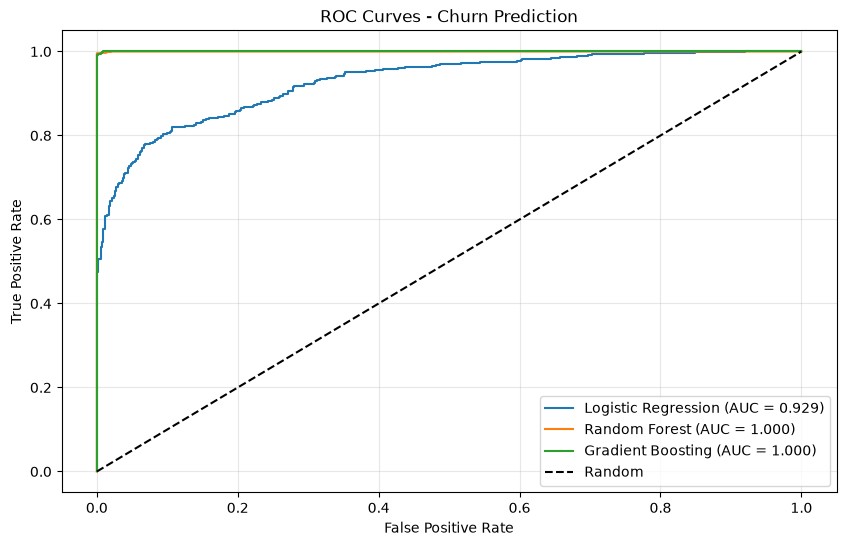

Model Comparison:
                     Precision  Recall     F1  ROC-AUC
Model                                                 
Logistic Regression      0.862   0.886  0.874    0.929
Random Forest            0.998   0.996  0.997    1.000
Gradient Boosting        0.999   0.995  0.997    1.000


In [6]:
# Scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Train and evaluate each model
results = []
plt.figure(figsize=(10, 6))

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
    
    y_pred = (y_prob >= 0.5).astype(int)
    
    # Metrics
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC-AUC': auc
    })
    
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Churn Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

results_df = pd.DataFrame(results).set_index('Model')
print("Model Comparison:")
print(results_df.round(3))

## Análisis de Importancia de Características

Entender qué características impulsan el abandono ayuda a diseñar intervenciones específicas.

Top 10 Churn Drivers:
                     feature  importance
4      days_since_last_login    0.594408
7                  nps_score    0.117704
2   support_tickets_last_6mo    0.092214
9            login_per_month    0.040680
1   login_frequency_per_week    0.037148
10       support_per_feature    0.035790
8            email_open_rate    0.034806
11         spend_per_feature    0.013237
5              monthly_spend    0.012285
0              tenure_months    0.009423


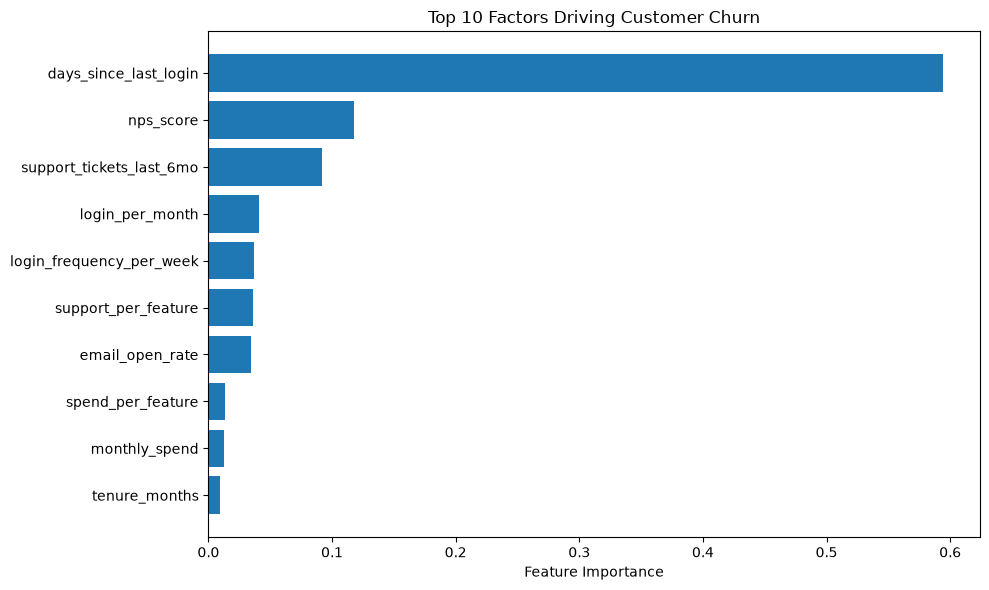

In [7]:
rf_model = models['Random Forest']
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Churn Drivers:")
print(importance_df.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'].head(10)[::-1], 
         importance_df['importance'].head(10)[::-1])
plt.xlabel('Feature Importance')
plt.title('Top 10 Factors Driving Customer Churn')
plt.tight_layout()
plt.show()

## Segmentación de Riesgo de Abandono e Impacto Empresarial

Segmentemos a los clientes por riesgo de abandono y calculemos los ahorros potenciales.

In [8]:
# Predict probabilities for all customers
all_prob = rf_model.predict_proba(X)[:, 1]
customers['churn_probability'] = all_prob

# Create risk segments
def risk_segment(prob):
    if prob < 0.2:
        return 'Low'
    elif prob <= 0.5:
        return 'Medium'
    else:
        return 'High'

customers['risk_segment'] = customers['churn_probability'].apply(risk_segment)

print("Churn Risk Distribution:")
segment_counts = customers['risk_segment'].value_counts()
for seg, count in segment_counts.items():
    actual_churn = customers[customers['risk_segment'] == seg]['churn'].mean()
    print(f"  {seg:8s}: {count:4d} customers (actual churn: {actual_churn:.1%})")

# Business impact calculation
high_risk = customers[customers['risk_segment'] == 'High']
monthly_revenue_at_risk = high_risk['monthly_spend'].sum()
print(f"\nMonthly revenue at risk (High risk): ${monthly_revenue_at_risk:,.0f}")

# Assume 50% of high-risk churners can be saved with intervention
save_rate = 0.5
annual_savings = monthly_revenue_at_risk * 12 * save_rate * 0.8  # 80% of high risk would actually churn
print(f"Estimated annual savings from churn interventions: ${annual_savings:,.0f}")

Churn Risk Distribution:
  High    : 3191 customers (actual churn: 100.0%)
  Low     : 1786 customers (actual churn: 0.0%)
  Medium  :   23 customers (actual churn: 17.4%)

Monthly revenue at risk (High risk): $333,615
Estimated annual savings from churn interventions: $1,601,351


## Estrategias de Intervención por Segmento

| Segmento | Riesgo | Acción |
|---|---|---|
| **Bajo** | <20% | Nutrir: compromiso regular, oportunidades de mejora |
| **Medio** | 20-50% | Involucrar: email personalizado, tutoriales de funciones, llamada de seguimiento |
| **Alto** | >50% | Retener: oferta de descuento, revisión de cuenta, contacto ejecutivo |

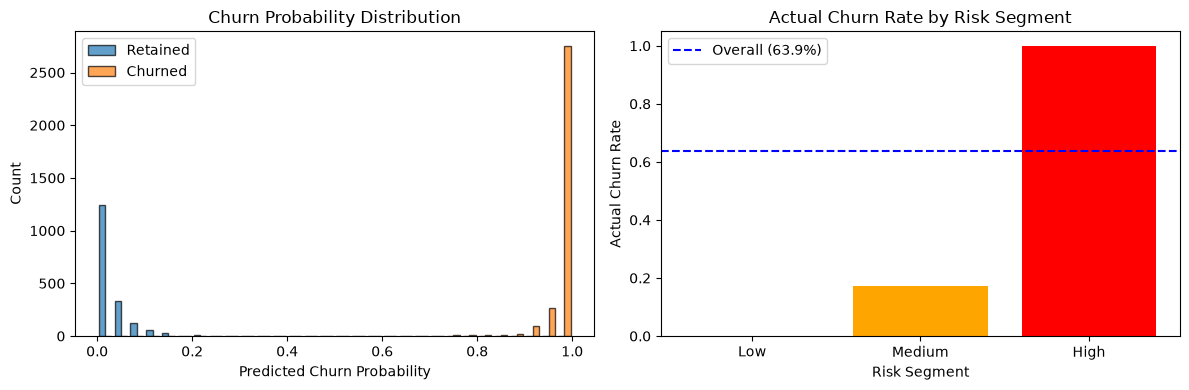

In [9]:
# Visualize churn probability distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist([
    customers[customers['churn'] == 0]['churn_probability'],
    customers[customers['churn'] == 1]['churn_probability']
], bins=30, label=['Retained', 'Churned'], alpha=0.7, edgecolor='black')
plt.xlabel('Predicted Churn Probability')
plt.ylabel('Count')
plt.title('Churn Probability Distribution')
plt.legend()

plt.subplot(1, 2, 2)
segment_order = ['Low', 'Medium', 'High']
segment_churn = [customers[customers['risk_segment'] == s]['churn'].mean() 
                 for s in segment_order]
plt.bar(segment_order, segment_churn, color=['green', 'orange', 'red'])
plt.xlabel('Risk Segment')
plt.ylabel('Actual Churn Rate')
plt.title('Actual Churn Rate by Risk Segment')
plt.axhline(y=customers['churn'].mean(), color='blue', linestyle='--', 
            label=f'Overall ({customers["churn"].mean():.1%})')
plt.legend()

plt.tight_layout()
plt.show()

## Ejercicios

1. Prueba un clasificador diferente (ej., SVM o XGBoost) y compara el rendimiento.
2. Optimiza el umbral de probabilidad para maximizar el valor empresarial (considera el costo de intervención vs. el costo del abandono).
3. Crea un mockup de panel de retención de clientes que muestre métricas clave y predicciones de IA.

In [10]:
# Exercise 1: XGBoost comparison
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(n_estimators=100, random_state=42)
    xgb.fit(X_train, y_train)
    xgb_prob = xgb.predict_proba(X_test)[:, 1]
    xgb_auc = roc_auc_score(y_test, xgb_prob)
    print(f"XGBoost ROC-AUC: {xgb_auc:.3f}")
except ImportError:
    print("XGBoost not installed. Try: pip install xgboost")

XGBoost not installed. Try: pip install xgboost


## Resumen

- La IA impulsa la predicción de abandono, personalización, analítica de marketing y analítica de producto en SaaS
- Construimos un pipeline de predicción de abandono con ingeniería de características, comparación de modelos y análisis de impacto empresarial
- Random Forest y Gradient Boosting funcionan bien para la predicción de abandono
- La importancia de características revela los impulsores del abandono → permite intervenciones específicas
- La segmentación de riesgo guía la estrategia de retención (Bajo: nutrir, Medio: involucrar, Alto: retener)
- El valor empresarial de la predicción de abandono es sustancial: millones en ingresos recuperados